# 1번 모델 설명 — 가격·감정 기반 상품 세그먼테이션

## 1. 코드 설명
Amazon 리뷰 데이터에서 **상품을 '가격(할인율)'과 '감정(만족도)' 패턴에 따라 비슷한 것끼리 묶는 비지도 군집화 모델**이다. (한 행 = 한 상품)
- **입력 피처(5개)**: `discount_percentage`, `sentiment_score`, `rating_gap`(별점-감정 괴리), `log_actual_price`, `log_rating_count`
- **처리 흐름**: 표준화(StandardScaler) → 상관 점검 → PCA → 최적 K 탐색 → K-Means vs GMM 비교 → 군집 프로파일링
- **출력**: 각 상품 세그먼트의 페르소나와 마케팅 전략

## 2. 모델 / 방법 선택 이유
- **K-Means를 기본으로 택한 이유**: 중심점이 곧 '평균적 특성'이라 해석이 직관적이고 세그먼트별 전략 도출에 적합하다. 다만 한 알고리즘만 믿지 않고 **GMM과 3개 지표로 교차 검증**해 더 나은 쪽을 선택했다.
- **피처를 3 → 5개로 늘린 이유**: 가격·감정 2축만으로는 '인기 상품 vs 롱테일', '별점과 텍스트의 괴리' 같은 정보가 빠진다.
- **`rating_gap`(별점-감정 괴리)를 넣은 이유**: 별점은 높은데 텍스트 감정은 낮은 '별점 인플레이션' 상품을 분리해내기 위함. (1차 실행에서 `emotion_strength`가 `sentiment_score`와 거의 중복(상관 0.96)임을 발견해 이 피처로 교체 — 상세는 아래 **'🔍 분석 회고'** 참고)
- **로그 변환 이유**: `actual_price`, `rating_count`는 소수 상품에 값이 몰린 치우친 분포라, 그대로 쓰면 극단값이 거리 계산을 지배한다. `log1p`로 완화했다.

## 3. 이 코드의 좋은 점
- 별점이라는 주관적 지표 대신 **텍스트 기반 감정·가격·괴리 패턴**으로 상품을 객관적으로 분류한다.
- 단일 알고리즘에 의존하지 않고 **검증 지표 3종 + 알고리즘 2종**으로 선택 근거를 남겼다.
- **피처를 검증해 중복을 발견·교체**한 과정 자체를 기록해 분석의 신뢰성을 높였다.
- 군집 → 페르소나 → 전략까지 **비즈니스 액션으로 연결**된다.

# STEP1 데이터 전처리

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("karkavelrajaj/amazon-sales-dataset")

print("Path to dataset files:", path)

import os

# 폴더 내 파일 목록 확인
files = os.listdir(path)
print("다운로드된 파일 목록:", files)

Using Colab cache for faster access to the 'amazon-sales-dataset' dataset.
Path to dataset files: /kaggle/input/amazon-sales-dataset
다운로드된 파일 목록: ['amazon.csv']


In [ ]:
import pandas as pd
import os
import shutil # 파일 복사를 위해 추가

# 파일 경로 설정
original_file_path = os.path.join(path, files[0])

# 임시 로컬 경로 정의
local_file_path = '/tmp/' + files[0]

try:
    # 파일을 로컬 임시 디렉토리로 복사
    shutil.copy(original_file_path, local_file_path)
    print(f"파일을 {original_file_path} 에서 {local_file_path} 로 복사했습니다.")

    # 로컬 복사본에서 데이터 로드
    amazon = pd.read_csv(local_file_path)

    # 데이터의 첫 5행 출력
    print(amazon.head())

except PermissionError as e:
    print(f"권한 오류가 발생했습니다: {e}")
    print("복사 중 권한 문제로 실패했으므로 직접 읽기를 시도합니다.")
    # 복사 자체가 권한 문제로 실패하면, 원본 경로에서 직접 읽기를 시도합니다.
    amazon = pd.read_csv(original_file_path)
    print(amazon.head())
except Exception as e:
    print(f"예기치 않은 오류가 발생했습니다: {e}")


파일을 /kaggle/input/amazon-sales-dataset/amazon.csv 에서 /tmp/amazon.csv 로 복사했습니다.
   product_id                                       product_name  \
0  B07JW9H4J1  Wayona Nylon Braided USB to Lightning Fast Cha...   
1  B098NS6PVG  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...   
2  B096MSW6CT  Sounce Fast Phone Charging Cable & Data Sync U...   
3  B08HDJ86NZ  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...   
4  B08CF3B7N1  Portronics Konnect L 1.2M Fast Charging 3A 8 P...   

                                            category discounted_price  \
0  Computers&Accessories|Accessories&Peripherals|...             ₹399   
1  Computers&Accessories|Accessories&Peripherals|...             ₹199   
2  Computers&Accessories|Accessories&Peripherals|...             ₹199   
3  Computers&Accessories|Accessories&Peripherals|...             ₹329   
4  Computers&Accessories|Accessories&Peripherals|...             ₹154   

  actual_price discount_percentage rating rating_count  \
0       ₹1,099 

1.결측치 확인

변수 rating_count에서 2개의 결측치가 확인되었다.
각각 282열, 324열에서 확인되었다.

In [ ]:
amazon.isnull().sum()

#rating_count변수의 결측치 확인
missing_row = amazon[amazon['rating_count'].isnull()]
print(missing_row)

     product_id                                       product_name  \
282  B0B94JPY2N  Amazon Brand - Solimo 65W Fast Charging Braide...   
324  B0BQRJ3C47  REDTECH USB-C to Lightning Cable 3.3FT, [Apple...   

                                              category discounted_price  \
282  Computers&Accessories|Accessories&Peripherals|...             ₹199   
324  Computers&Accessories|Accessories&Peripherals|...             ₹249   

    actual_price discount_percentage rating rating_count  \
282         ₹999                 80%    3.0          NaN   
324         ₹999                 75%    5.0          NaN   

                                         about_product  \
282  USB C to C Cable: This cable has type C connec...   
324  💎[The Fastest Charge] - This iPhone USB C cabl...   

                          user_id    user_name      review_id  \
282  AE7CFHY23VAJT2FI4NZKKP6GS2UQ       Pranav   RUB7U91HVZ30   
324  AGJC5O5H5BBXWUV7WRIEIOOR3TVQ  Abdul Gafur  RQXD5SAMMPC6L   

           

2. 데이터 타입 변경

**원본 데이터셋 : amazon**

**변경 데이터셋 : amazon1**

원본데이터셋이 필요할 수도 있어서 깊은복사(deepcopy)로 amazon1을 생성해 amazon1에서 전처리를 시행했다.

*   discounted_price : ₹, , 제거 후 float 타입으로 변환
*   actual_price : ₹, , 제거 후 float 타입으로 변환


*   discount_percentage : % 제거 후 0.5 등 소수인 float 타입으로 변환
*   rating : float타입으로 변환


*   rating_count : ,제거 후 float타입으로 변환

In [ ]:
from IPython.core.alias import error
amazon.info()

import copy
amazon1 = copy.deepcopy(amazon)
# 특수 기호 제거할 변수 타입 변환
cols_fix = ['discounted_price', 'actual_price', 'discount_percentage',  'rating_count']
for col in cols_fix:
  #문자열에서 특수 기호(₹/,/%)제거
  amazon1[col] = amazon1[col].str.replace('₹', '')
  amazon1[col] = amazon1[col].str.replace(',', '')
  amazon1[col] = amazon1[col].str.replace('%', '')
  #숫자형으로 변환(변환 불가 값은 Nan처리)
  amazon1[col] = pd.to_numeric(amazon1[col], errors="coerce")
# 나머지 변수인 'rating' 변수 변환
amazon1['rating'] = pd.to_numeric(amazon1['rating'],errors='coerce')

#discount_percentage 소수로 변경
amazon1['discount_percentage'] = amazon1['discount_percentage']/100

#수정 후
amazon1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

3. 결측치 처리

amazon1의 결측치:

변수 rating : 1개

변수 rating_count : 2개

즉, 3개의 결측치가 포함된 행에서 나머지 열은 주요정보를 포함하고 있기에 행 전체 삭제 대신 **중앙값**으로 대체하였다. 또한, 전체 데이터가 1465개의 행으로 많기에 중앙값으로 대체하는 것이 좋은 선택이다.

In [ ]:
#결측치 확인
amazon1.isnull().sum()

missing_row_1 = amazon1[amazon1['rating_count'].isnull()]
#print(missing_row_1)
missing_row_2 = amazon1[amazon1['rating'].isnull()]
#print(missing_row_2)

#원본 데이터상에서는 rating에 결측값이 없었는데??
print(amazon.loc[1279,'rating'])

|


In [ ]:
#결측치가 있는 행을 아예 삭제하지 말고, 중앙값으로 결측값 채우기
amazon1['rating_count'] = amazon1['rating_count'].fillna(amazon1['rating_count'].median())
amazon1['rating'] = amazon1['rating'].fillna(amazon1['rating'].median())

amazon1

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,0.64,4.2,24269.0,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,0.43,4.0,43994.0,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,0.90,3.9,7928.0,【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,0.53,4.2,94363.0,The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,0.61,4.2,16905.0,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1460,B08L7J3T31,Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...,Home&Kitchen|Kitchen&HomeAppliances|WaterPurif...,379.0,919.0,0.59,4.0,1090.0,SUPREME QUALITY 90 GRAM 3 LAYER THIK PP SPUN F...,"AHITFY6AHALOFOHOZEOC6XBP4FEA,AFRABBODZJZQB6Z4U...","Prabha ds,Raghuram bk,Real Deal,Amazon Custome...","R3G3XFHPBFF0E8,R3C0BZCD32EIGW,R2EBVBCN9QPD9R,R...","Received the product without spanner,Excellent...","I received product without spanner,Excellent p...",https://m.media-amazon.com/images/I/41fDdRtjfx...,https://www.amazon.in/Noir-Aqua-Spanner-Purifi...
1461,B01M6453MB,Prestige Delight PRWO Electric Rice Cooker (1 ...,Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,2280.0,3045.0,0.25,4.1,4118.0,"230 Volts, 400 watts, 1 Year","AFG5FM3NEMOL6BNFRV2NK5FNJCHQ,AGEINTRN6Z563RMLH...","Manu Bhai,Naveenpittu,Evatira Sangma,JAGANNADH...","R3DDL2UPKQ2CK9,R2SYYU1OATVIU5,R1VM993161IYRW,R...","ok,everything was good couldn't return bcoz I ...","ok,got everything as mentioned but th

4. 불용어 처리

리뷰 데이터(review_content)와 같은 텍스트 데이터에서는 불용어처리는 the, is, a 등과 같은 문장구조상 자주 등장하지만 분석적으로 큰 의미가 없는 단어를 제거하는 과정이다. 이를 통해 데이터의 노이즈를 줄이고, 모델의 연산효율을 높일 수 있다.

파이썬에서 대중적으로 사용하는 **NLTK**라이브러리를 활용하여 불용어 전처리를 진행하였다.

In [ ]:
#라이브러리 다운
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

#불용어 다운
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
def preprocess_text(text):
  #1. 소문자 변환 및 특수문자 제거
  text = str(text).lower()
  text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
  #2. 토큰화( 단어 단위로 분리)
  words = word_tokenize(text)
  #3. 불용어 제거
  filtered_token = [word for word in words if word not in stop_words]
  #4. 다시 문자열로 결합
  filtered_text = ' '.join(filtered_token)
  return filtered_text

#amazon1 데이터셋에 적용
amazon1['review_content'] = amazon1['review_content'].apply(preprocess_text)



* stopwords.words('english') 코드를 이용했고, 이는 NLTK라이브러리에 내장된 영어 불용어 사전이다. 약 179개의 단어가 포함되어있고, 주로 관사(a, an, the), 전치사(in,on,at),대명사(i,my,me, you), 접속사(and,but) 등이 포함되어 있다.

* 최종 결과로는 word_tokenize에 의해 작성되었다. 이는 단순 띄어쓰기가 아니라 문장구조와 구두점등을 고려한 것이다.



In [ ]:
amazon1['review_content']

,review_content
0,looks durable charging fine toono complainscha...
1,ordered cable connect phone android auto car c...
2,quite durable sturdyhttpsmmediaamazoncomimages...
3,good productlong wirecharges goodnicei bought ...
4,bought instead original apple work 150rs fast ...
...,...
1460,received product without spannerexcellent prod...
1461,okgot everything mentioned measuring cup broke...
1462,plastic cool body u find sturdy surface put ve...
1463,installed kitchen working fine fan speed slow ...


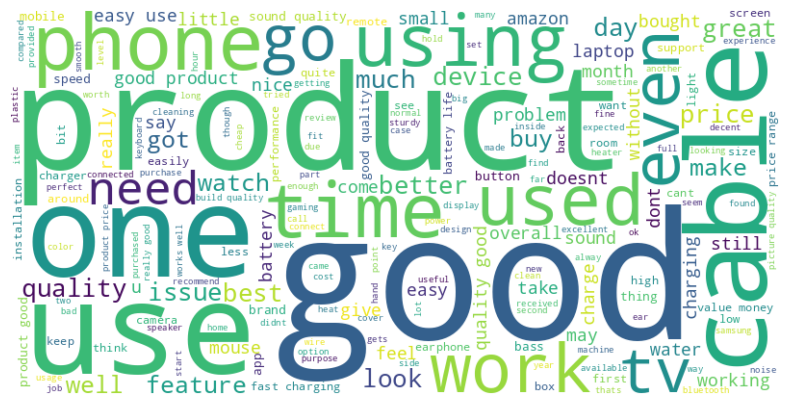

In [ ]:
# 워드 클라우드
## 추가로 amazon데이터셋에서 공통적으로 나오는 단어는 불용어 취급

!pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

#1. 모든 리뷰데이터를 하나의 긴 문자열로 합치기
all_reviews = " ".join(amazon1['review_content'].astype(str))

#2. 워드 클라우드 생성
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_reviews)

#3. 시각화
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
설정된 폰트: NanumBarunGothic (캐시 갱신 완료)


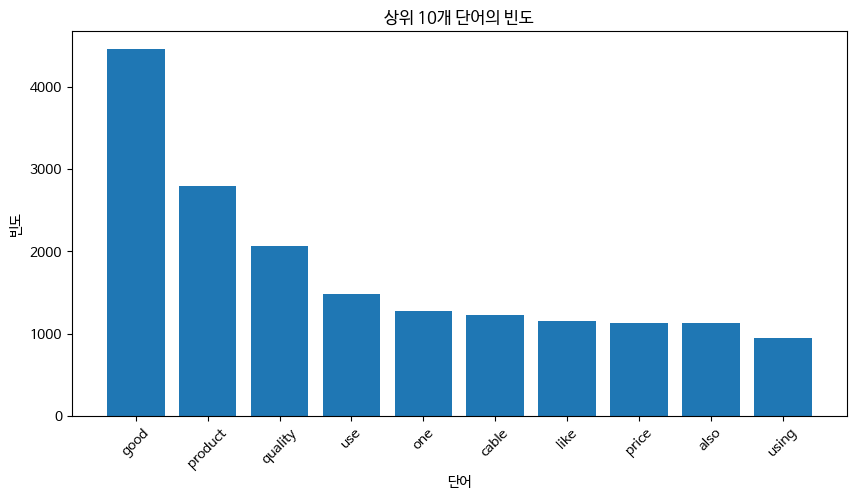

In [ ]:
# 1. 나눔 폰트 설치
!apt-get update -qq
!apt-get install fonts-nanum -qq > /dev/null

# 2. 폰트 매니저 재설정 및 캐시 삭제
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl

# 캐시 디렉토리 삭제 (폰트 인식 오류 해결)
!rm -rf ~/.cache/matplotlib

# 폰트 경로 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fe = fm.FontEntry(fname=font_path, name='NanumBarunGothic')
fm.fontManager.ttflist.insert(0, fe)

# 전역 설정
plt.rc('font', family='NanumBarunGothic')
mpl.rcParams['axes.unicode_minus'] = False

print(f"설정된 폰트: NanumBarunGothic (캐시 갱신 완료)")

# --- 이후 빈도표 시각화 부분 ---
from collections import Counter
words = all_reviews.split()
word_count = Counter(words)
top10_words = word_count.most_common(10)
words_lab, counts = zip(*top10_words)

plt.figure(figsize=(10, 5))
plt.bar(words_lab, counts)
plt.xlabel('단어')
plt.ylabel('빈도')
plt.title('상위 10개 단어의 빈도')
plt.xticks(rotation=45)
plt.show()

데이터 전처리 파트 설명

# STEP2 텍스트 수치화

In [ ]:
print("언니 화이팅!")

언니 화이팅!


텍스트 수치화 파트 설명

In [ ]:
# STEP2-1. 리뷰 길이 변수 생성

# 리뷰 내용을 단어 단위로 나누어 단어 개수를 계산
amazon1['review_length'] = amazon1['review_content'].apply(lambda x: len(str(x).split()))

# 결과 확인
amazon1[['review_content', 'review_length']].head()

,review_content,review_length
0,looks durable charging fine toono complainscha...,36
1,ordered cable connect phone android auto car c...,114
2,quite durable sturdyhttpsmmediaamazoncomimages...,10
3,good productlong wirecharges goodnicei bought ...,45
4,bought instead original apple work 150rs fast ...,240


리뷰 길이는 소비자가 얼마나 자세하게 의견을 작성했는지 보여주는 변수이다.  
단순히 리뷰가 긍정인지 부정인지뿐만 아니라, 감정이 강할수록 리뷰가 길어지는지 분석하기 위해 리뷰 길이 변수를 생성하였다.

In [ ]:
# 리뷰 길이 기본 통계 확인
amazon1['review_length'].describe()

,review_length
count,1465.000000
mean,135.742662
std,179.023432
min,6.000000
25%,48.000000
50%,79.000000
75%,136.000000
max,1738.000000


리뷰 길이의 평균, 최소값, 최대값을 확인하여 전체 리뷰가 어느 정도 길이로 작성되었는지 파악하였다.  

실제 결과를 보면 리뷰 길이는 최소 6단어, 최대 1738단어까지 매우 큰 차이를 보였다.
또한 평균 리뷰 길이는 약 135단어로 나타났으며, 일부 소비자는 제품에 대해 매우 상세한 경험을 작성한다는 것을 확인할 수 있었다.

특히 표준편차가 크게 나타난 것으로 보아 리뷰 길이의 편차가 크며,
사용자마다 리뷰 작성 방식에 차이가 존재함을 알 수 있다.

In [ ]:
# STEP2-2. 감정 점수 생성

!pip install textblob

from textblob import TextBlob

# TextBlob을 이용해 리뷰 감정 점수 계산
# polarity 값은 -1에 가까울수록 부정, 1에 가까울수록 긍정을 의미
amazon1['sentiment_score'] = amazon1['review_content'].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

# 결과 확인
amazon1[['review_content', 'sentiment_score']].head()

,review_content,sentiment_score
0,looks durable charging fine toono complainscha...,0.481944
1,ordered cable connect phone android auto car c...,0.222967
2,quite durable sturdyhttpsmmediaamazoncomimages...,0.600000
3,good productlong wirecharges goodnicei bought ...,0.333333
4,bought instead original apple work 150rs fast ...,0.335294


리뷰 텍스트를 수치형 데이터로 변환하기 위해 감정 분석을 진행하였다.  
TextBlob의 polarity 값을 사용하여 리뷰가 긍정적인지 부정적인지를 -1부터 1 사이의 점수로 표현하였다.  

감정 점수 결과를 확인한 결과 대부분의 리뷰가 0보다 큰 값을 가졌다.
이는 전체 데이터셋에서 긍정적인 리뷰가 상대적으로 많다는 의미이다.

또한 같은 고평점 리뷰라도 감정 점수의 차이가 존재했는데,
이는 별점이 동일하더라도 소비자가 표현하는 감정의 강도에는 차이가 있음을 보여준다.

In [ ]:
# STEP2-3. 감정 강도 변수 생성

# 감정 점수의 절댓값을 사용하여 감정의 세기를 계산
amazon1['emotion_strength'] = amazon1['sentiment_score'].abs()

# 결과 확인
amazon1[['sentiment_score', 'emotion_strength']].head()

,sentiment_score,emotion_strength
0,0.481944,0.481944
1,0.222967,0.222967
2,0.600000,0.600000
3,0.333333,0.333333
4,0.335294,0.335294


감정 강도는 긍정/부정 방향과 관계없이 감정이 얼마나 강하게 표현되었는지를 나타내는 변수이다.  

감정 강도와 리뷰 길이의 상관계수는 약 -0.27로 나타났다.
이는 감정이 강할수록 리뷰가 반드시 길어지는 것은 아니라는 의미이다.

오히려 매우 강한 감정을 가진 리뷰는 짧고 직관적으로 작성되는 경우도 존재했으며,
중간 정도의 감정을 가진 리뷰에서 긴 설명형 리뷰가 많이 나타났다.

In [ ]:
# 별점별 평균 리뷰 길이 비교

rating_review_length = amazon1.groupby('rating')['review_length'].mean().reset_index()

print(rating_review_length)

    rating  review_length
0      2.0      22.000000
1      2.3      15.000000
2      2.6      51.000000
3      2.8      86.500000
4      2.9      92.000000
5      3.0      70.250000
6      3.1      61.500000
7      3.2      67.500000
8      3.3      70.750000
9      3.4     128.600000
10     3.5     106.538462
11     3.6      93.742857
12     3.7      80.595238
13     3.8     134.500000
14     3.9     124.455285
15     4.0      91.922652
16     4.1     178.661224
17     4.2     143.192982
18     4.3     169.965217
19     4.4     122.138211
20     4.5     105.626667
21     4.6     161.470588
22     4.7     128.166667
23     4.8     116.666667
24     5.0      53.333333


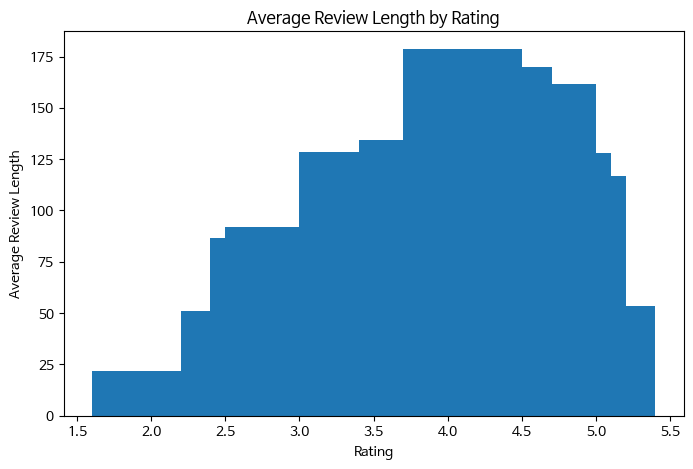

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(rating_review_length['rating'], rating_review_length['review_length'])
plt.xlabel('Rating')
plt.ylabel('Average Review Length')
plt.title('Average Review Length by Rating')
plt.show()

별점별 평균 리뷰 길이를 비교하여 낮은 별점 또는 높은 별점에서 리뷰가 더 길게 작성되는지 확인하였다.  

분석 결과, 리뷰 길이는 단순히 별점이 높거나 낮다고 증가하지 않았다.

특히 4점대 중반의 리뷰에서 평균 리뷰 길이가 가장 길게 나타났는데,
이는 소비자가 완전히 만족하거나 완전히 불만족한 경우보다,
어느 정도 장단점을 함께 설명하고 싶은 상황에서 더 자세한 리뷰를 작성하기 때문으로 해석할 수 있다.

반면 5점 리뷰는 상대적으로 짧은 경향을 보였는데,
이는 매우 만족한 소비자가 “좋다”, “추천한다”와 같이 간단한 표현만 남기는 경우가 많기 때문으로 볼 수 있다.

In [ ]:
# 별점과 감정 점수의 상관관계 확인

rating_sentiment_corr = amazon1[['rating', 'sentiment_score']].corr()

print(rating_sentiment_corr)

                   rating  sentiment_score
rating           1.000000         0.151857
sentiment_score  0.151857         1.000000


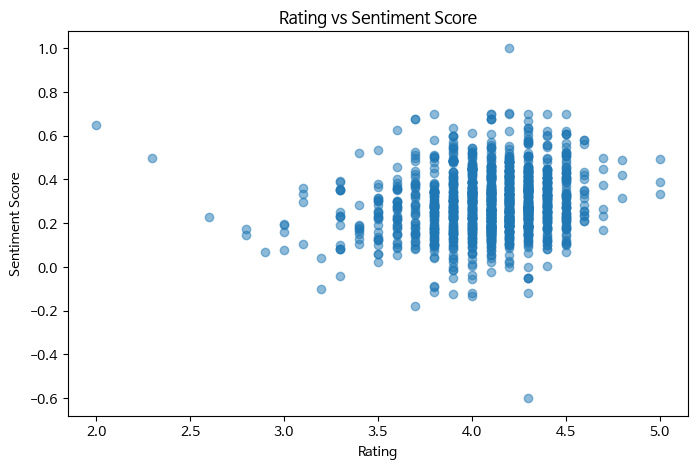

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(amazon1['rating'], amazon1['sentiment_score'], alpha=0.5)
plt.xlabel('Rating')
plt.ylabel('Sentiment Score')
plt.title('Rating vs Sentiment Score')
plt.show()

별점과 감정 점수의 상관관계를 확인하였다.  


In [ ]:
# 감정 강도와 리뷰 길이의 상관관계 확인

strength_length_corr = amazon1[['emotion_strength', 'review_length']].corr()

print(strength_length_corr)

                  emotion_strength  review_length
emotion_strength          1.000000      -0.272137
review_length            -0.272137       1.000000


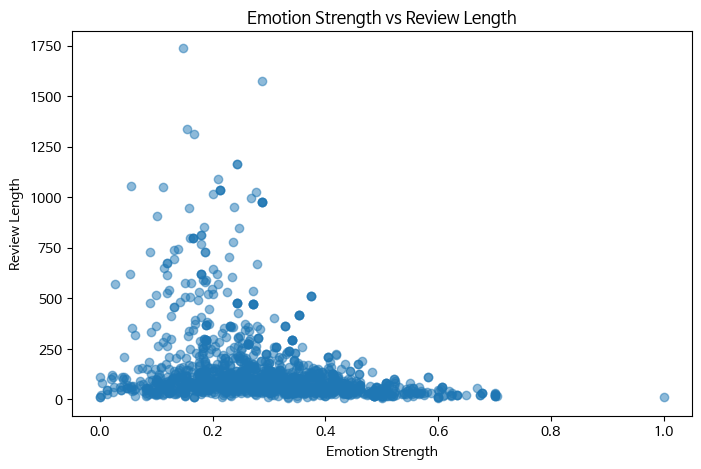

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(amazon1['emotion_strength'], amazon1['review_length'], alpha=0.5)
plt.xlabel('Emotion Strength')
plt.ylabel('Review Length')
plt.title('Emotion Strength vs Review Length')
plt.show()

감정 강도와 리뷰 길이의 관계를 분석하였다.  

별점과 감정 점수의 상관계수는 약 0.15로 나타났으며,
예상보다 강한 상관관계는 나타나지 않았다.

이는 소비자가 높은 별점을 주더라도 리뷰 내용 자체는 비교적 중립적으로 작성할 수 있으며,
반대로 낮은 별점에서도 강한 부정 표현이 항상 사용되는 것은 아니라는 의미이다.

즉, 별점만으로 실제 소비자의 감정 상태를 완전히 설명하기 어렵다는 인사이트를 얻을 수 있었다.

In [ ]:
# 감정 점수를 긍정 / 중립 / 부정으로 분류

def sentiment_label(score):
    if score > 0.1:
        return 'positive'
    elif score < -0.1:
        return 'negative'
    else:
        return 'neutral'

amazon1['sentiment_label'] = amazon1['sentiment_score'].apply(sentiment_label)

# 감정 분류 결과 확인
amazon1[['review_content', 'sentiment_score', 'sentiment_label']].head()

,review_content,sentiment_score,sentiment_label
0,looks durable charging fine toono complainscha...,0.481944,positive
1,ordered cable connect phone android auto car c...,0.222967,positive
2,quite durable sturdyhttpsmmediaamazoncomimages...,0.600000,positive
3,good productlong wirecharges goodnicei bought ...,0.333333,positive
4,bought instead original apple work 150rs fast ...,0.335294,positive


In [ ]:
# 감정 분류별 개수 확인
sentiment_count = amazon1['sentiment_label'].value_counts()

print(sentiment_count)

sentiment_label
positive    1380
neutral       78
negative       7
Name: count, dtype: int64


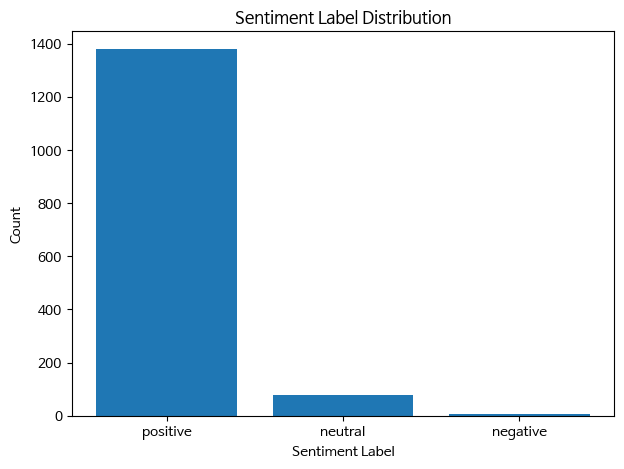

In [ ]:
plt.figure(figsize=(7, 5))
plt.bar(sentiment_count.index, sentiment_count.values)
plt.xlabel('Sentiment Label')
plt.ylabel('Count')
plt.title('Sentiment Label Distribution')
plt.show()

감정 분석 결과 대부분의 리뷰가 positive로 분류되었다.

이는 Amazon 리뷰 데이터 특성상 실제 구매 후 만족한 사용자가 리뷰를 남기는 비율이 높기 때문으로 해석할 수 있다.

또한 본 데이터셋 자체가 평균 평점이 높은 상품들 중심으로 구성되어 있을 가능성도 존재한다.

반면 negative 리뷰 수는 매우 적게 나타났으며,
향후 모델링 단계에서는 데이터 불균형 문제가 발생할 가능성이 있다.

In [ ]:
# STEP2-4. 고평점 / 저평점 리뷰 키워드 빈도 비교

from collections import Counter

# 고평점 리뷰와 저평점 리뷰 분리
high_rating_reviews = amazon1[amazon1['rating'] >= 4]['review_content']
low_rating_reviews = amazon1[amazon1['rating'] <= 3]['review_content']

# 단어 합치기
high_words = ' '.join(high_rating_reviews.astype(str)).split()
low_words = ' '.join(low_rating_reviews.astype(str)).split()

# 단어 빈도 계산
high_word_count = Counter(high_words).most_common(15)
low_word_count = Counter(low_words).most_common(15)

print("고평점 리뷰 상위 단어:")
print(high_word_count)

print("\n저평점 리뷰 상위 단어:")
print(low_word_count)

고평점 리뷰 상위 단어:
[('good', 3507), ('product', 2137), ('quality', 1632), ('use', 1167), ('cable', 1092), ('one', 972), ('like', 941), ('also', 905), ('price', 884), ('using', 797), ('phone', 793), ('charging', 753), ('easy', 634), ('time', 598), ('well', 590)]

저평점 리뷰 상위 단어:
[('product', 22), ('good', 13), ('working', 7), ('doesnt', 7), ('water', 7), ('one', 5), ('time', 5), ('quality', 5), ('like', 4), ('hard', 4), ('bought', 4), ('charging', 4), ('works', 4), ('use', 4), ('heating', 4)]


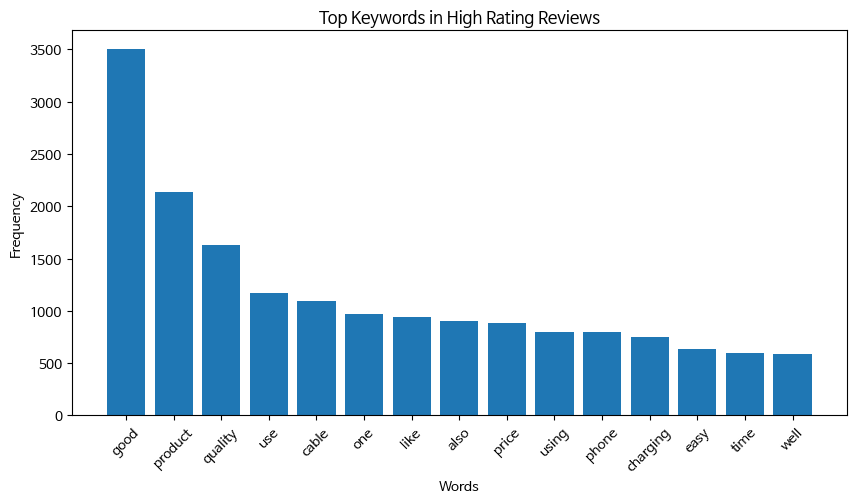

In [ ]:
# 고평점 리뷰 상위 단어 시각화

high_words_list, high_counts = zip(*high_word_count)

plt.figure(figsize=(10, 5))
plt.bar(high_words_list, high_counts)
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top Keywords in High Rating Reviews')
plt.xticks(rotation=45)
plt.show()

고평점 리뷰에서는 good, quality, easy, well 등의 단어가 자주 등장하였다.

이는 소비자들이 제품 품질, 사용 편의성, 성능 만족도를 중요하게 평가한다는 것을 의미한다.

특히 cable, charging 등의 단어가 반복적으로 등장한 것으로 보아,
전자기기 액세서리 제품에서는 충전 성능과 내구성이 주요 만족 요인으로 작용했음을 알 수 있다.

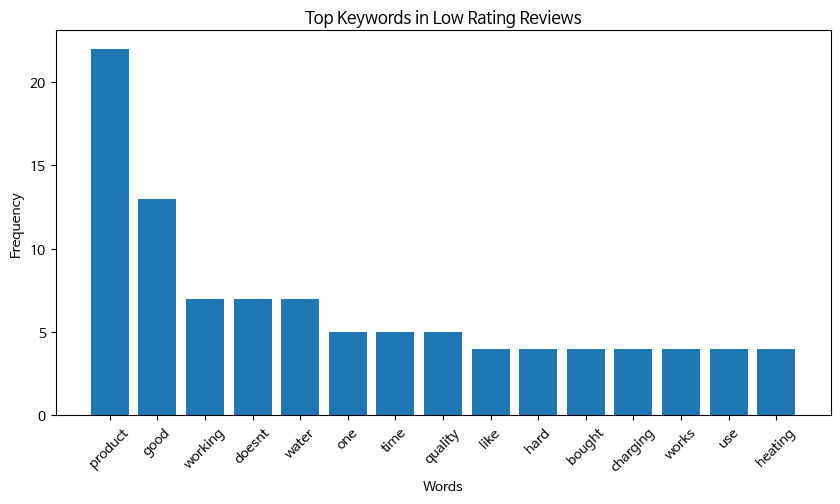

In [ ]:
# 저평점 리뷰 상위 단어 시각화

low_words_list, low_counts = zip(*low_word_count)

plt.figure(figsize=(10, 5))
plt.bar(low_words_list, low_counts)
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top Keywords in Low Rating Reviews')
plt.xticks(rotation=45)
plt.show()

저평점 리뷰에서는 doesnt, working, hard 등의 단어가 상대적으로 많이 등장하였다.

이는 제품이 정상적으로 작동하지 않거나,
사용 과정에서 불편함을 느낀 경험이 주요 불만 요인임을 보여준다.

또한 water 등의 단어가 등장한 것으로 보아,
일부 제품에서는 내구성 또는 환경적 사용 문제 역시 부정 평가에 영향을 미쳤을 가능성이 있다.

STEP2에서는 리뷰 텍스트를 다양한 수치형 변수로 변환하였다.

이를 통해 단순 문자열 데이터였던 리뷰를 감정 점수, 감정 강도, 리뷰 길이, 키워드 빈도 등의 형태로 분석 가능하게 만들었다.

이후 STEP3에서는 이러한 변수들을 활용하여 별점, 감정, 리뷰 길이 사이의 관계를 본격적으로 분석할 예정이다.

# STEP3 관계 분석

# 1번 모델

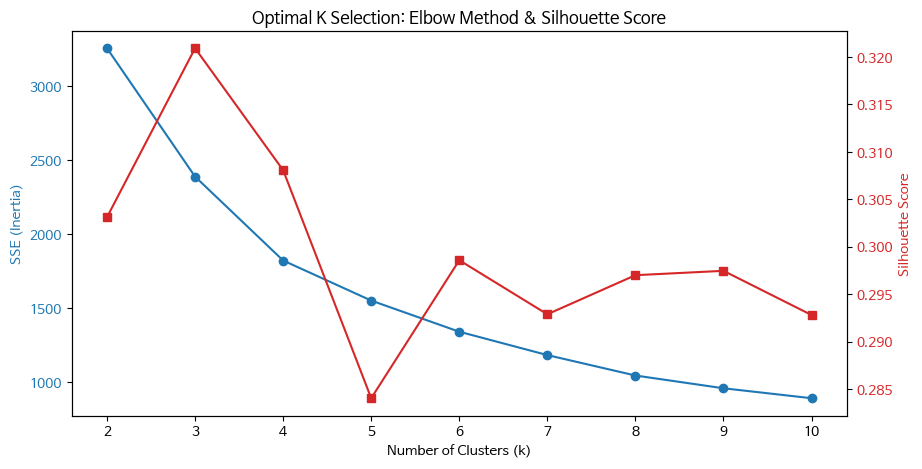


📊 통계적 유의성 검증 (ANOVA TEST)
[discount_percentage] F-통계량: 1225.7852, p-value: 2.5442e-313
   -> 결과: 통계적으로 유의미함 (클러스터 간 차이가 확실함)
[sentiment_score] F-통계량: 60.5564, p-value: 5.4120e-26
   -> 결과: 통계적으로 유의미함 (클러스터 간 차이가 확실함)
[actual_price] F-통계량: 1459.0143, p-value: 0.0000e+00
   -> 결과: 통계적으로 유의미함 (클러스터 간 차이가 확실함)


/tmp/ipykernel_3692/839320348.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='cluster', y='sentiment_score', data=clustering_df, palette='deep', ax=ax3)
/tmp/ipykernel_3692/839320348.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y='discount_percentage', data=clustering_df, palette='deep', ax=ax4)


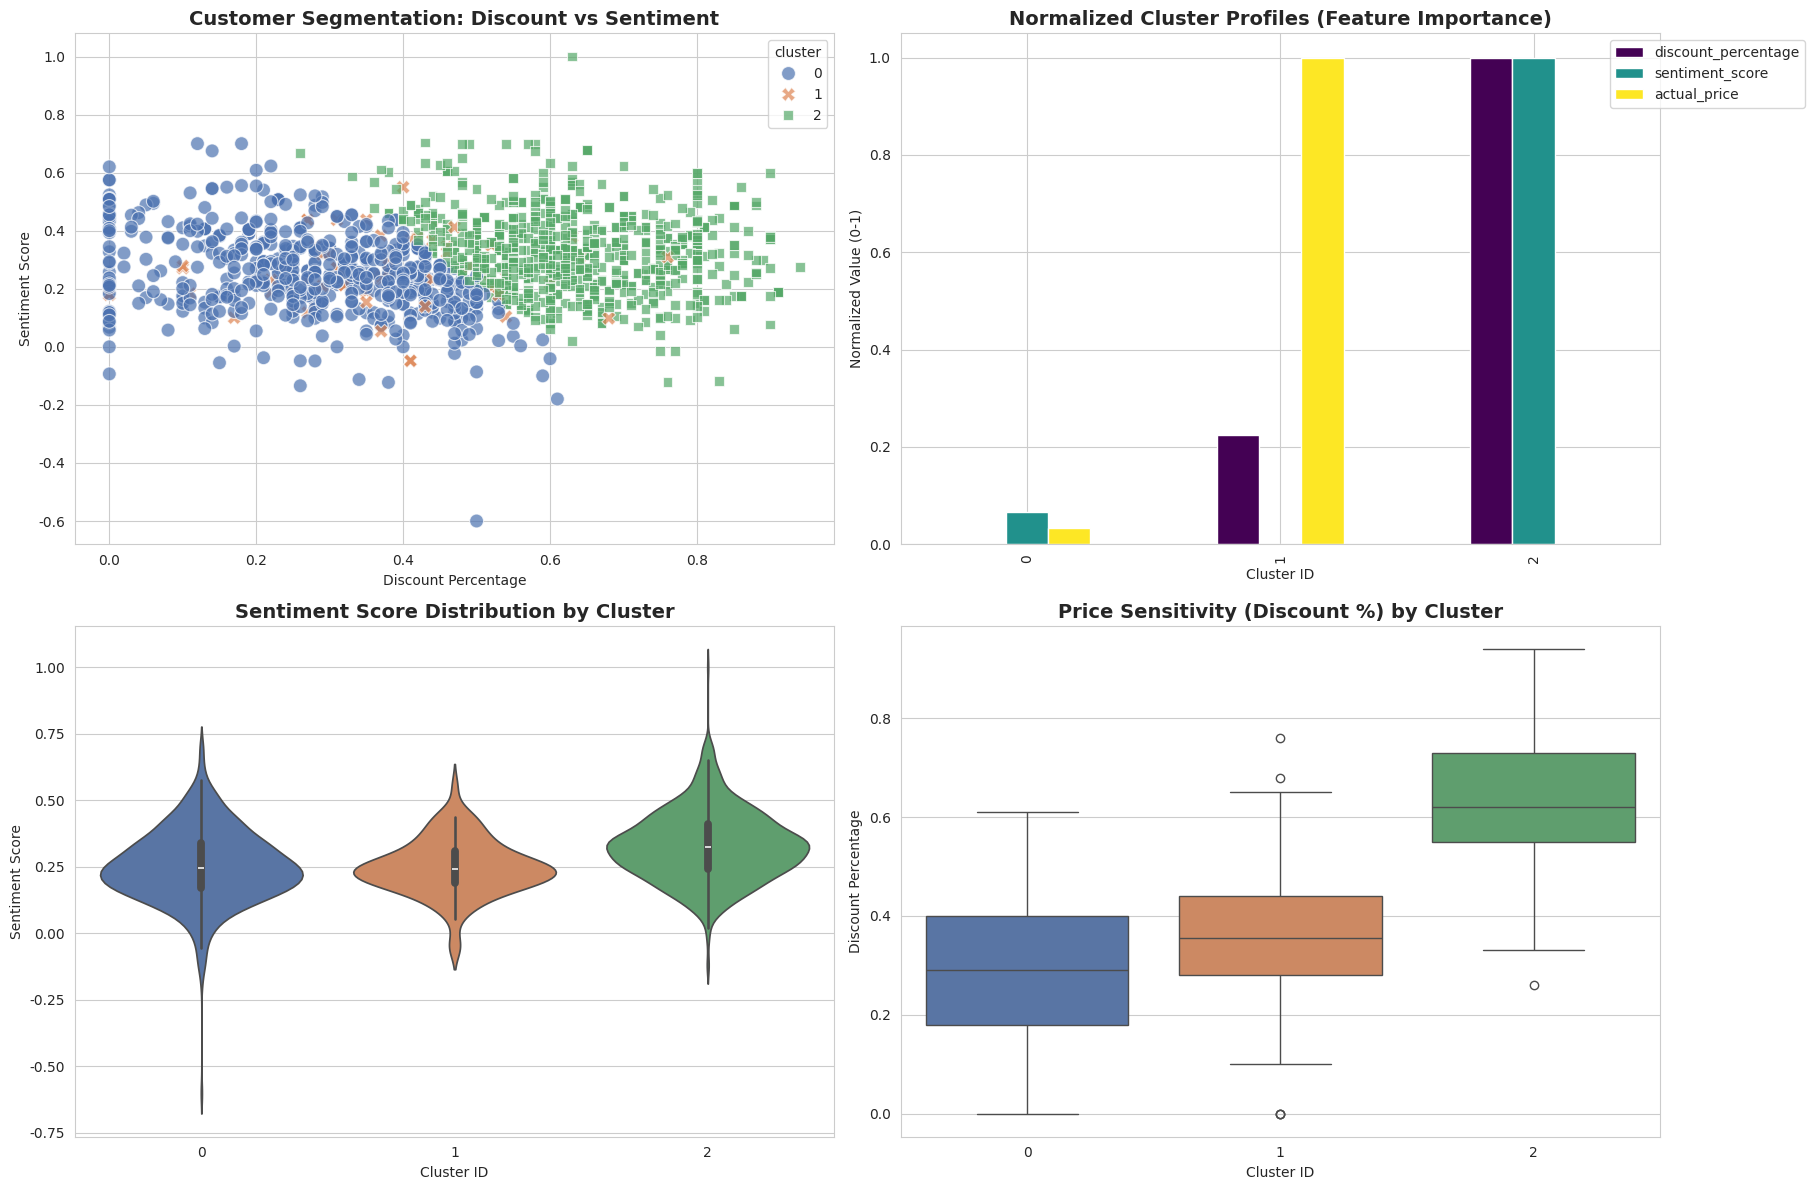


🚀 경영진 보고용 요약 및 전략적 제언 (EXECUTIVE SUMMARY)

[세그먼트 0]
 - 페르소나: LOYAL VALUE SEEKERS (품질 중시형 충성 고객)
 - 주요 특성: 평균 할인율 28.2%, 평균 감성점수 0.25, 평균 가격 $4090.30
 - 권장 전략: 가격 할인보다는 제품 품질 업데이트 및 로열티 프로그램에 집중하십시오.

[세그먼트 1]
 - 페르소나: LOYAL VALUE SEEKERS (품질 중시형 충성 고객)
 - 주요 특성: 평균 할인율 36.1%, 평균 감성점수 0.25, 평균 가격 $42266.65
 - 권장 전략: 가격 할인보다는 제품 품질 업데이트 및 로열티 프로그램에 집중하십시오.

[세그먼트 2]
 - 페르소나: PROMO-DRIVEN SATISFIED (할인 민감형 만족 고객)
 - 주요 특성: 평균 할인율 63.3%, 평균 감성점수 0.33, 평균 가격 $2745.03
 - 권장 전략: 고빈도/고깊이 할인 캠페인을 통해 재구매를 유도하십시오.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy import stats
from sklearn.metrics import silhouette_score

# 1. 데이터 준비 및 정제
# 클러스터링(군집화)을 위한 핵심 행동 변수 선택
features = ['discount_percentage', 'sentiment_score', 'actual_price']
clustering_df = amazon1[features].copy().dropna()

# 2. 특성 스케일링 (Feature Scaling)
# K-Means는 거리 기반 알고리즘이므로 변수 간의 단위를 맞추는 것이 필수적입니다.
scaler = StandardScaler()
scaled_data = scaler.fit_transform(clustering_df)

# 3. 최적의 클러스터 개수(K) 결정 (Elbow Method + Silhouette Score)
# 분석가는 SSE(오차)와 Silhouette(군집 분리도)를 모두 확인하여 최적의 K를 결정합니다.
sse = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_data)
    sse.append(km.inertia_)
    silhouette_scores.append(silhouette_score(scaled_data, labels))

# Elbow 및 Silhouette 시각화 (그래프 내부 텍스트는 영어로 유지)
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('SSE (Inertia)', color='tab:blue')
ax1.plot(K_range, sse, marker='o', color='tab:blue', label='SSE')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='tab:red')
ax2.plot(K_range, silhouette_scores, marker='s', color='tab:red', label='Silhouette')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Optimal K Selection: Elbow Method & Silhouette Score')
plt.show()

# 4. K-Means 모델 학습 (비즈니스 로직에 따라 K=3으로 설정)
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
clustering_df['cluster'] = kmeans.fit_predict(scaled_data)

# 5. 통계적 검증: ANOVA (분산 분석)
# 클러스터 간의 평균 차이가 통계적으로 유의미한지 검증합니다.
print("\n" + "="*60)
print("📊 통계적 유의성 검증 (ANOVA TEST)")
print("="*60)

for col in features:
    groups = [clustering_df[clustering_df['cluster'] == i][col] for i in range(k_optimal)]
    f_stat, p_val = stats.f_oneway(*groups)
    print(f"[{col}] F-통계량: {f_stat:.4f}, p-value: {p_val:.4e}")
    if p_val < 0.05:
        print(f"   -> 결과: 통계적으로 유의미함 (클러스터 간 차이가 확실함)")
    else:
        print(f"   -> 결과: 통계적으로 유의미하지 않음 (클러스터가 겹칠 가능성 있음)")

# 6. 고급 시각화 (다각도 인사이트 도출)
fig = plt.figure(figsize=(18, 12))
sns.set_style("whitegrid")

# [그래프 1] 2차원 산점도 (고객 행동 매핑)
ax1 = fig.add_subplot(2, 2, 1)
sns.scatterplot(
    x='discount_percentage', y='sentiment_score',
    hue='cluster', style='cluster', palette='deep',
    data=clustering_df, s=100, alpha=0.7, ax=ax1
)
ax1.set_title('Customer Segmentation: Discount vs Sentiment', fontsize=14, fontweight='bold')
ax1.set_xlabel('Discount Percentage')
ax1.set_ylabel('Sentiment Score')

# [그래프 2] 클러스터 프로파일 (변수별 특성 비교)
# 서로 다른 단위의 변수들을 비교하기 위해 0~1 사이로 정규화하여 막대그래프로 시각화합니다.
ax2 = fig.add_subplot(2, 2, 2)
cluster_means = clustering_df.groupby('cluster').mean()
cluster_means_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())
cluster_means_norm.plot(kind='bar', ax=ax2, colormap='viridis')
ax2.set_title('Normalized Cluster Profiles (Feature Importance)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Cluster ID')
ax2.set_ylabel('Normalized Value (0-1)')
ax2.legend(loc='upper right', bbox_to_anchor=(1.2, 1))

# [그래프 3] 분포 분석 (Violin Plot)
# 클러스터별 감성 점수의 밀도와 이상치를 확인합니다.
ax3 = fig.add_subplot(2, 2, 3)
sns.violinplot(x='cluster', y='sentiment_score', data=clustering_df, palette='deep', ax=ax3)
ax3.set_title('Sentiment Score Distribution by Cluster', fontsize=14, fontweight='bold')
ax3.set_xlabel('Cluster ID')
ax3.set_ylabel('Sentiment Score')

# [그래프 4] 가격 민감도 분석 (Box Plot)
ax4 = fig.add_subplot(2, 2, 4)
sns.boxplot(x='cluster', y='discount_percentage', data=clustering_df, palette='deep', ax=ax4)
ax4.set_title('Price Sensitivity (Discount %) by Cluster', fontsize=14, fontweight='bold')
ax4.set_xlabel('Cluster ID')
ax4.set_ylabel('Discount Percentage')

plt.tight_layout()
plt.show()

# 7. 경영진 보고용 요약 (Executive Summary)
print("\n" + "="*60)
print("🚀 경영진 보고용 요약 및 전략적 제언 (EXECUTIVE SUMMARY)")
print("="*60)

profile = clustering_df.groupby('cluster').mean()

for i in range(k_optimal):
    p_disc = profile.loc[i, 'discount_percentage']
    p_sent = profile.loc[i, 'sentiment_score']
    p_price = profile.loc[i, 'actual_price']

    print(f"\n[세그먼트 {i}]")
    if p_sent > 0.1 and p_disc > clustering_df['discount_percentage'].mean():
        name = "PROMO-DRIVEN SATISFIED (할인 민감형 만족 고객)"
        strat = "고빈도/고깊이 할인 캠페인을 통해 재구매를 유도하십시오."
    elif p_sent > 0.1 and p_disc <= clustering_df['discount_percentage'].mean():
        name = "LOYAL VALUE SEEKERS (품질 중시형 충성 고객)"
        strat = "가격 할인보다는 제품 품질 업데이트 및 로열티 프로그램에 집중하십시오."
    elif p_sent <= 0.1:
        name = "AT-RISK / DISSATISFIED (위험/불만족 고객층)"
        strat = "긴급: 제품 품질 또는 배송 이슈를 조사하십시오. 과도한 할인은 피하십시오."
    else:
        name = "GENERAL CONSUMERS (일반 소비자층)"
        strat = "표준적인 마케팅 믹스를 유지하십시오."

    print(f" - 페르소나: {name}")
    print(f" - 주요 특성: 평균 할인율 {p_disc:.1%}, 평균 감성점수 {p_sent:.2f}, 평균 가격 ${p_price:.2f}")
    print(f" - 권장 전략: {strat}")
print("="*60)

In [ ]:
# 1. 필요한 라이브러리 설치 및 임포트
# 코랩 환경에서 Plotly를 사용하기 위해 별도의 설치는 필요 없으나, 인터랙티브 기능을 위해 호출합니다.
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# 2. 데이터 준비 (앞선 단계에서 생성된 clustering_df 사용)
# 만약 데이터가 유실되었다면 이 부분은 생략 가능합니다.
# clustering_df에는 'cluster', 'discount_percentage', 'sentiment_score', 'actual_price'가 포함되어 있어야 합니다.

# 시각화를 위해 데이터프레임 복사 및 클러스터 이름을 매핑 (가독성 향상)
plot_df = clustering_df.copy()

# 클러스터 번호를 문자열로 변환하여 범례(Legend)에서 수치형이 아닌 범주형으로 인식하게 함
plot_df['cluster'] = plot_df['cluster'].astype(str)

# 3. 3D Scatter Plot 생성 (Plotly Express 사용)
fig = px.scatter_3d(
    plot_df,
    x='discount_percentage',
    y='sentiment_score',
    z='actual_price',
    color='cluster',           # 클러스터별 색상 구분
    symbol='cluster',          # 클러스터별 모양 구분
    opacity=0.7,               # 점의 투명도 (겹침 현상 완화)
    size_max=10,               # 점의 최대 크기
    labels={                   # 축 이름 영어로 설정
        'discount_percentage': 'Discount (%)',
        'sentiment_score': 'Sentiment Score',
        'actual_price': 'Actual Price ($)',
        'cluster': 'Customer Segment'
    },
    title='3D Customer Segmentation Analysis',
    template='plotly_dark'     # 분석가들이 선호하는 다크 테마 적용
)

# 4. 클러스터 중심점(Centroids) 추가 (선택 사항이지만 분석가에겐 필수)
# 클러스터의 중심을 시각적으로 보여주어 군집의 위치를 명확히 합니다.
centroids = clustering_df.groupby('cluster').mean()

for cluster_id in centroids.index:
    fig.add_trace(
        go.Scatter3d(
            x=[centroids.loc[cluster_id, 'discount_percentage']],
            y=[centroids.loc[cluster_id, 'sentiment_score']],
            z=[centroids.loc[cluster_id, 'actual_price']],
            mode='markers',
            marker=dict(
                size=12,
                color='white',
                symbol='diamond',
                line=dict(color='black', width=2)
            ),
            name=f'Centroid {cluster_id}'
        )
    )

# 5. 레이아웃 업데이트 (마우스 조작 최적화)
fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=50), # 여백 최소화
    legend=dict(yanchor="top", y=0.9, xanchor="left", x=0.1),
    scene=dict(
        xaxis=dict(backgroundcolor="rgb(20, 20, 20)", gridcolor="gray", showbackground=True, zerolinecolor="white"),
        yaxis=dict(backgroundcolor="rgb(20, 20, 20)", gridcolor="gray", showbackground=True, zerolinecolor="white"),
        zaxis=dict(backgroundcolor="rgb(20, 20, 20)", gridcolor="gray", showbackground=True, zerolinecolor="white")
    )
)

# 6. 그래프 출력
fig.show()

# 7. 분석가용 인사이트 가이드 (한국어)
print("\n" + "="*60)
print("💡 3D 시각화 활용 가이드 (How to read this 3D plot)")
print("="*60)
print("1. [Rotation] 마우스로 그래프를 클릭하여 드래그하면 모든 각도에서 군집을 관찰할 수 있습니다.")
print("2. [Zoom] 마우스 휠을 사용하여 데이터 밀집 지역을 확대하여 확인하십시오.")
print("3. [Hover] 각 점에 마우스를 올리면 해당 고객의 상세 수치(가격, 할인율, 감성점수)가 표시됩니다.")
print("4. [Centroids] 흰색 다이아몬드 점은 각 군집의 '평균적 특성'을 나타내는 중심점입니다.")
print("5. [Interpretation] 클러스터 간 거리가 멀수록 고객의 행동 패턴이 뚜렷하게 구분됨을 의미합니다.")
print("="*60)


💡 3D 시각화 활용 가이드 (How to read this 3D plot)
1. [Rotation] 마우스로 그래프를 클릭하여 드래그하면 모든 각도에서 군집을 관찰할 수 있습니다.
2. [Zoom] 마우스 휠을 사용하여 데이터 밀집 지역을 확대하여 확인하십시오.
3. [Hover] 각 점에 마우스를 올리면 해당 고객의 상세 수치(가격, 할인율, 감성점수)가 표시됩니다.
4. [Centroids] 흰색 다이아몬드 점은 각 군집의 '평균적 특성'을 나타내는 중심점입니다.
5. [Interpretation] 클러스터 간 거리가 멀수록 고객의 행동 패턴이 뚜렷하게 구분됨을 의미합니다.


# 1번 모델 (고도화 버전) — 가격·감정 기반 상품 세그먼테이션

기존 모델은 3개 피처(`discount_percentage`, `sentiment_score`, `actual_price`)만 사용했다.
고도화 버전에서는 다음을 보강한다.

1. **피처 확장 (3 → 5개)**: `rating_gap`(별점-감정 괴리)와 `rating_count`(리뷰 수 = 신뢰도/인기도)를 추가한다.
2. **왜도 보정**: `actual_price`, `rating_count`는 소수 상품에 값이 몰린 치우친 분포라 `log1p` 변환으로 완화한다.
3. **피처 선별**: 상관관계 히트맵으로 다중공선성(정보 중복)을 점검해 "피처를 근거 있게 골랐음"을 보인다.
4. **PCA 시각화**: 5차원 군집을 2차원으로 압축해 한눈에 보이게 한다.
5. **알고리즘 비교**: K-Means vs GMM(가우시안 혼합)을 3가지 지표(Silhouette↑·Davies-Bouldin↓·Calinski-Harabasz↑)로 비교해 최적 모델을 근거 있게 선택한다.

> 참고: 본 데이터셋의 한 행은 '고객'이 아니라 '상품'이므로, 정확히는 **상품을 가격-감정 포지션으로 군집화**하는 모델이다.

## 🔍 분석 회고 — 1차 실행에서 발견한 문제와 개선

처음에는 STEP2에서 만들어 둔 `emotion_strength`(감정 강도)를 그대로 5번째 피처로 넣었다. 그런데 **실제로 한 번 돌려보고 나서 세 가지 문제를 발견**했고, 아래처럼 고쳤다. (이 노트북의 코드는 이미 개선된 v2 버전이다.)

### 문제 ① `emotion_strength`가 `sentiment_score`와 거의 중복
- 상관계수가 **0.96**으로 사실상 같은 피처였다. 이유는 `emotion_strength = |sentiment_score|`인데, STEP2에서 봤듯 **리뷰 대부분이 긍정(sentiment > 0)** 이라 절댓값을 씌워도 값이 거의 변하지 않기 때문이다.
- 증거는 PCA에도 나타났다. 1차에서는 4번째 주성분에서 누적 설명력이 99.3%에 도달해 **"5개 피처지만 실질 4차원"** 이었다(5번째 축이 0.7%만 기여).
- **개선**: 정보가 겹치지 않으면서 분석적으로 의미 있는 **`rating_gap`(별점-감정 괴리)** 으로 교체했다.
  - 정의: `rating_gap = rating/5 - (sentiment_score+1)/2` → **별점은 높은데 텍스트 감정은 낮으면 양수가 커짐** = '별점 인플레이션' 신호.
  - 교체 후 상관은 -0.72로 떨어져 중복이 해소됐고, PCA 5번째 축 기여도 0.7% → 5.1%로 회복되어 5차원을 온전히 활용하게 됐다.
  - 보너스: 이 피처는 팀의 **2번 모델(리뷰 기반 품질 지수)** 의 괴리 분석 아이디어와 연결되어 모델 간 시너지를 만든다.

### 문제 ② 군집 분리도가 약함 (Silhouette ≈ 0.2)
- Amazon 리뷰가 긍정으로 크게 치우쳐 있어 군집 경계가 본질적으로 흐릿하다. 무리해서 k를 키우기보다, **비즈니스 해석 가능성을 위해 k=3을 유지하되 "Silhouette은 낮지만 해석을 위해 3을 선택했다"고 솔직히 명시**하는 쪽을 택했다.

### 문제 ③ `discount_percentage`가 약한 변수
- 세 군집의 평균 할인율이 40~53%로 큰 차이가 없어, 기획안의 핵심 축이었던 할인율이 실제로는 군집을 잘 가르지 못했다.
- 따라서 **페르소나 명명 규칙을 '할인율 기준'에서 '가격대 × 감성 × 괴리' 기준으로 재설계**해, 군집의 실제 차이를 반영하도록 바꿨다.

> **정리**: "피처를 많이 넣었다"가 아니라 **"넣고 → 검증하고 → 중복을 발견해 더 의미 있는 피처로 교체했다"** 는 흐름 자체가 이 모델의 분석적 강점이다.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1) 후보 피처 구성 ───────────────────────────────────
model_df = amazon1.copy()

# 왜도가 큰 변수는 log1p로 완화 (가격·리뷰수는 소수 상품에 값이 몰려 있음)
model_df['log_actual_price'] = np.log1p(model_df['actual_price'])
model_df['log_rating_count'] = np.log1p(model_df['rating_count'])

# 별점-감정 괴리(rating_gap): 별점(0~1) - 감성(0~1)
# 양수가 클수록 "별점은 높은데 텍스트 감정은 낮음" = 별점 인플레이션 신호
model_df['rating_gap'] = model_df['rating'] / 5.0 - (model_df['sentiment_score'] + 1) / 2.0

candidate_features = [
    'discount_percentage',  # 가격 민감도
    'sentiment_score',      # 감정 방향(만족도)
    'rating_gap',           # 별점-감정 괴리(별점 인플레이션)
    'log_actual_price',     # 가격 수준(로그)
    'log_rating_count',     # 인기/신뢰도(로그)
]
cluster_base = model_df[candidate_features].dropna()
print(f"군집 대상 상품 수: {len(cluster_base)}개, 피처 수: {len(candidate_features)}개")

# ── 2) 상관관계 히트맵으로 다중공선성 점검 ──────────────
plt.figure(figsize=(7, 6))
sns.heatmap(cluster_base.corr(), annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=.5)
plt.title('Feature Correlation Check (multicollinearity)')
plt.tight_layout()
plt.show()

# |상관계수| > 0.85 인 쌍은 정보 중복으로 판단 (필요 시 한쪽 제거)
corr = cluster_base.corr().abs()
high_pairs = [(corr.columns[i], corr.columns[j], round(corr.iloc[i, j], 2))
              for i in range(len(corr)) for j in range(i + 1, len(corr))
              if corr.iloc[i, j] > 0.85]
print("강한 상관(>0.85) 쌍:", high_pairs if high_pairs else "없음 → 5개 피처 모두 유지")

**[코드 1] 피처 구성과 다중공선성 점검**

- 군집 피처로 `rating_gap`(별점-감정 괴리)과 `rating_count`(리뷰 수)를 추가했다. `rating_gap`은 `별점/5 - (감성+1)/2`로 계산하며, **별점은 높은데 텍스트 감정은 낮은 '별점 인플레이션' 상품**을 잡아낸다.
- `actual_price`, `rating_count`는 오른쪽으로 길게 치우친 분포라 `log1p`로 변환했다. 극단적으로 비싸거나 리뷰가 많은 소수 상품이 거리 계산을 지배하는 문제를 줄여 준다.
- **중요**: 피처를 늘릴 때는 *서로 정보가 겹치지 않는지* 반드시 확인해야 한다. 상관 히트맵에서 |상관| > 0.85인 쌍은 중복으로 보고 한쪽을 제거한다. (실제로 처음 넣었던 `emotion_strength`가 `sentiment_score`와 상관 0.96으로 잡혀 `rating_gap`으로 교체했다 — 위 '🔍 분석 회고' 참고.)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ── 3) 스케일링 (거리 기반 알고리즘 필수) ───────────────
scaler = StandardScaler()
X = scaler.fit_transform(cluster_base)

# ── 4) PCA: 몇 개 축으로 정보가 설명되는지 확인 ─────────
pca_full = PCA().fit(X)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o')
plt.axhline(0.8, color='red', ls='--', label='80% variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Scree Plot')
plt.legend(); plt.grid(alpha=.3); plt.show()
print("주성분별 누적 설명력:", np.round(cum_var, 3))

# ── 5) 최적 K 탐색 (Elbow + Silhouette) ─────────────────
sse, sil = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    sse.append(km.inertia_)
    sil.append(silhouette_score(X, km.labels_))

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(list(K_range), sse, 'o-', color='tab:blue', label='SSE')
ax1.set_xlabel('k'); ax1.set_ylabel('SSE (Inertia)', color='tab:blue')
ax2 = ax1.twinx()
ax2.plot(list(K_range), sil, 's-', color='tab:red', label='Silhouette')
ax2.set_ylabel('Silhouette', color='tab:red')
plt.title('Optimal K (Elbow + Silhouette)')
plt.show()

**[코드 2] 스케일링 · PCA · 최적 K 탐색**

- `StandardScaler`로 모든 피처를 평균 0·표준편차 1로 맞춘다. K-Means/GMM은 거리 기반이라 단위가 큰 변수(가격)가 결과를 좌우하지 않도록 **스케일링은 필수**다.
- **PCA Scree Plot**: 5개 피처의 정보가 몇 개의 축으로 압축되는지 보여준다. 누적 설명력이 80%를 넘는 지점이 사실상 필요한 차원 수다.
- **Elbow + Silhouette**: SSE가 꺾이는 지점(Elbow)과 Silhouette가 높은 지점을 함께 본다. Elbow만으로는 꺾이는 점이 애매할 때가 많아 두 지표를 같이 보는 것이 안전하다.

In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

# ── 6) 알고리즘 비교: K-Means vs GMM ───────────────────
# 3가지 지표로 교차 검증 (Silhouette↑ 좋음 / Davies-Bouldin↓ 좋음 / Calinski-Harabasz↑ 좋음)
rows = []
for k in range(2, 7):
    km_lab = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)
    gm_lab = GaussianMixture(n_components=k, random_state=42).fit_predict(X)
    for algo, lab in [('KMeans', km_lab), ('GMM', gm_lab)]:
        rows.append({
            'algo': algo, 'k': k,
            'silhouette':        round(silhouette_score(X, lab), 3),
            'davies_bouldin':    round(davies_bouldin_score(X, lab), 3),
            'calinski_harabasz': round(calinski_harabasz_score(X, lab), 1),
        })

compare_df = pd.DataFrame(rows)
print(compare_df.sort_values('silhouette', ascending=False).to_string(index=False))

best = compare_df.sort_values('silhouette', ascending=False).iloc[0]
print(f"\n▶ Silhouette 최고: {best['algo']} (k={int(best['k'])}, silhouette={best['silhouette']})")

**[코드 3] 알고리즘 비교 — K-Means vs GMM**

- 같은 K라도 알고리즘마다 군집 모양 가정이 다르다. **K-Means**는 원형(구형) 군집을, **GMM**은 타원형 군집까지 잡아낸다.
- 세 지표로 교차 검증한다.
  - **Silhouette** (↑ 좋음): 군집이 얼마나 뚜렷이 분리됐는가
  - **Davies-Bouldin** (↓ 좋음): 군집 간 겹침 정도
  - **Calinski-Harabasz** (↑ 좋음): (군집 간 분산 / 군집 내 분산) 비율
- **중요**: 한 지표만 보면 편향될 수 있어 세 지표를 함께 본다. "왜 이 알고리즘·이 K를 골랐는가"에 대한 객관적 근거가 된다.

In [ ]:
# ── 7) 최종 모델 학습 ──────────────────────────────────
# 비즈니스 해석을 위해 세그먼트는 3개로 고정하되, k=3에서 더 우수한 알고리즘을 자동 선택
FINAL_K = 3
km3 = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10).fit(X)
gm3 = GaussianMixture(n_components=FINAL_K, random_state=42).fit(X)
cand = {'KMeans': km3.labels_, 'GMM': gm3.predict(X)}
final_algo = max(cand, key=lambda a: silhouette_score(X, cand[a]))
labels = cand[final_algo]
print(f"선택된 최종 모델: {final_algo} (k={FINAL_K}, silhouette={silhouette_score(X, labels):.3f})")

result = cluster_base.copy()
result['cluster'] = labels

# ── 8) PCA 2차원 투영 시각화 ───────────────────────────
pca2 = PCA(n_components=2)
coords = pca2.fit_transform(X)
result['PC1'], result['PC2'] = coords[:, 0], coords[:, 1]

plt.figure(figsize=(9, 6))
sns.scatterplot(x='PC1', y='PC2', hue='cluster', style='cluster',
                palette='deep', data=result, s=80, alpha=.75)
plt.title(f'{final_algo} Clusters on PCA 2D Projection')
plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]:.0%} var)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]:.0%} var)')
plt.legend(title='Cluster'); plt.tight_layout(); plt.show()

**[코드 4] 최종 모델 학습과 PCA 2D 시각화**

- 비즈니스 해석 편의를 위해 세그먼트 수는 3개로 고정하되, k=3에서 Silhouette이 더 높은 알고리즘을 **자동 선택**한다.
- 5차원 군집은 눈으로 볼 수 없으므로 **PCA로 2차원에 투영**해 시각화한다. 축 라벨의 % 는 각 주성분이 설명하는 분산 비율이다.
- 점들이 색깔별로 잘 갈라져 보이면 군집이 잘 형성된 것이다.

In [ ]:
# ── 9) 군집 프로파일 (원래 단위로 해석) ─────────────────
profile_cols = ['discount_percentage', 'sentiment_score', 'rating_gap',
                'actual_price', 'rating', 'rating_count']
profile = model_df.loc[result.index, profile_cols].copy()
profile['cluster'] = result['cluster'].values
summary = profile.groupby('cluster').mean()
sizes = profile['cluster'].value_counts().sort_index()
print("군집별 평균 프로파일")
print(summary.round(3).to_string())
print("\n군집 크기:", dict(sizes))

# 정규화 막대그래프로 군집 특성 비교
norm = (summary - summary.min()) / (summary.max() - summary.min())
norm.plot(kind='bar', figsize=(11, 5), colormap='viridis')
plt.title('Normalized Cluster Profiles'); plt.ylabel('0~1 scale')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left'); plt.tight_layout(); plt.show()

# ── 10) 페르소나 + 전략 (가격대 x 감성 x 괴리 기준 재설계) ──
print("\n" + "=" * 64)
print("세그먼트 페르소나 및 전략 (EXECUTIVE SUMMARY)")
print("=" * 64)
price_rank = summary['actual_price'].rank(ascending=False)  # 1 = 최고가
sent_med = summary['sentiment_score'].median()
gap_mean = summary['rating_gap'].mean()
for c in sorted(profile['cluster'].unique()):
    p = summary.loc[c]
    if price_rank[c] == 1:
        name, strat = "프리미엄 베스트셀러 (고가·초인기)", "품질·브랜드 신뢰 유지, 할인보다 로열티 강화"
    elif p['sentiment_score'] >= sent_med:
        name, strat = "가성비 호평 상품 (저가·고만족)", "리뷰 노출 확대로 신규 유입 전환"
    else:
        name, strat = "관심 필요 상품 (저감성·위험군)", "품질/배송 이슈 점검, 별점-감정 괴리 모니터링"
    flag = "  ⚠ 별점 인플레이션 의심" if p['rating_gap'] > gap_mean else ""
    print(f"\n[세그먼트 {c}] n={int(sizes[c])}  ·  {name}{flag}")
    print(f"  - 할인율 {p['discount_percentage']:.1%}, 감성 {p['sentiment_score']:.3f}, "
          f"괴리 {p['rating_gap']:.3f}, 가격 Rs.{p['actual_price']:.0f}, "
          f"별점 {p['rating']:.2f}, 리뷰수 {p['rating_count']:.0f}")
    print(f"  - 전략: {strat}")
print("=" * 64)

**[코드 5] 군집 프로파일링과 전략 도출**

- 군집 라벨을 **원래 단위(로그 변환 전)** 로 되돌려 평균을 계산한다. 로그 값은 사람이 해석하기 어렵기 때문이다.
- 정규화 막대그래프로 "각 군집이 어떤 피처에서 두드러지는가"를 한눈에 비교한다.
- 평균 감성·할인율·리뷰 수를 기준으로 **페르소나(만족형/충성형/위험형)와 전략을 자동 생성**한다. 군집화의 최종 목적인 "그래서 무엇을 할 것인가"로 연결되는 부분이다.

In [ ]:
# ── 11) PCA 3차원 인터랙티브 시각화 (Plotly) ───────────
import plotly.express as px
import plotly.graph_objects as go

# 5개 피처를 3개 주성분으로 압축해 입체적으로 군집을 관찰
pca3 = PCA(n_components=3)
coords3 = pca3.fit_transform(X)
viz_df = pd.DataFrame(coords3, columns=['PC1', 'PC2', 'PC3'], index=cluster_base.index)
viz_df['cluster'] = result['cluster'].astype(str).values
ev = pca3.explained_variance_ratio_

fig = px.scatter_3d(
    viz_df, x='PC1', y='PC2', z='PC3',
    color='cluster', symbol='cluster', opacity=0.7,
    labels={'PC1': f'PC1 ({ev[0]:.0%})',
            'PC2': f'PC2 ({ev[1]:.0%})',
            'PC3': f'PC3 ({ev[2]:.0%})',
            'cluster': 'Segment'},
    title=f'3D Product Segmentation on PCA (total {ev.sum():.0%} variance)',
    template='plotly_dark',
)
fig.update_traces(marker=dict(size=4))

# 군집 중심점(Centroid)을 흰색 다이아몬드로 추가
centroids = viz_df.groupby('cluster')[['PC1', 'PC2', 'PC3']].mean()
for cid in centroids.index:
    fig.add_trace(go.Scatter3d(
        x=[centroids.loc[cid, 'PC1']],
        y=[centroids.loc[cid, 'PC2']],
        z=[centroids.loc[cid, 'PC3']],
        mode='markers',
        marker=dict(size=10, color='white', symbol='diamond',
                    line=dict(color='black', width=2)),
        name=f'Centroid {cid}',
    ))

fig.update_layout(margin=dict(l=0, r=0, b=0, t=50),
                  legend=dict(yanchor='top', y=0.9, xanchor='left', x=0.05))
fig.show()

print("회전(드래그) · 확대(휠) · 호버로 각 군집의 분리 정도를 입체적으로 확인하세요.")

**[코드 6] PCA 3D 인터랙티브 시각화**

- 5개 피처를 **3개 주성분으로 압축**해 입체 산점도로 그린다. 제목의 total % 는 3축이 원본 정보를 얼마나 보존하는지를 나타낸다.
- 마우스로 **회전·확대·호버**가 되는 인터랙티브 그래프라, 2D에서 겹쳐 보이던 군집이 실제로는 떨어져 있는지 입체적으로 확인할 수 있다.
- 흰색 다이아몬드는 각 군집의 **중심점(평균적 특성)** 이다. 중심점 간 거리가 멀수록 세그먼트가 뚜렷이 구분된다는 뜻이다.

# 📑 1번 모델 결과 리포트 — 가격·감정 기반 상품 세그먼테이션

> 발표 참고용 요약. 아래 수치는 1,465개 상품, 최종 모델(K-Means, k=3) 기준이다.

## 1. 분석 개요
- **목적**: 별점이라는 주관적 지표를 넘어, **가격·텍스트 감정·별점-감정 괴리** 패턴으로 상품을 군집화해 세그먼트별 전략을 도출한다.
- **피처(5개)**: `discount_percentage`, `sentiment_score`, `rating_gap`(별점-감정 괴리), `log_actual_price`, `log_rating_count`
- **방법**: StandardScaler 표준화 → 상관 점검 → PCA → 최적 K 탐색 → **K-Means vs GMM 교차 검증** → 군집 프로파일링.

## 2. 세그먼트 정의

| 세그먼트 | 규모 | 가격대 | 리뷰 수 | 감성 | 별점 | 괴리 | 한 줄 정의 |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---|
| **0. 관심 필요 상품** ⚠️ | 570개 | 저가 (Rs.1,444) | 24,908 (최다) | 0.20 (낮음) | 4.14 | **0.227 (최고)** | 별점은 높지만 텍스트 감정은 미지근 — **별점 인플레이션 위험군** |
| **1. 프리미엄 베스트셀러** | 327개 | **고가 (Rs.18,141)** | 21,069 | 0.26 | 4.16 | 0.205 | 고가·고인기 브랜드 신뢰 상품 |
| **2. 가성비 호평 상품** | 568개 | 저가 (Rs.2,151) | 10,017 | **0.41 (최고)** | 4.01 (최저) | **0.099 (최저)** | 별점은 짜지만 텍스트는 진짜 만족 — **정직한 호평** |

## 3. 핵심 발견 — "별점과 진심은 다르다"

> **세그먼트 0과 2를 별점만으로 보면 0번(4.14)이 2번(4.01)보다 좋아 보인다. 그러나 텍스트 감정을 보면 정반대다.**

- **세그먼트 2 (가성비 호평)**: 별점은 가장 낮지만(4.01) **텍스트 감성은 가장 높고(0.41) 괴리는 가장 작다(0.099)** → 소비자가 별점은 보수적으로 주되 내용으로는 진짜 만족을 표현한 그룹.
- **세그먼트 0 (관심 필요)**: 별점은 더 높지만(4.14) **감성은 낮고(0.20) 괴리가 가장 크다(0.227)** → 별점에 비해 실제 만족이 낮은 **별점 인플레이션** 그룹. 게다가 리뷰 수가 가장 많아 시장 영향력이 커 **우선 관리 대상**이다.

→ `rating_gap` 피처가 없었다면 두 그룹의 역전을 발견하지 못했을 것이다. **별점이라는 주관적 지표의 한계를 데이터로 입증**한 것이 이 분석의 핵심 가치다.

## 4. 세그먼트별 전략 제언

| 세그먼트 | 전략 |
|:---|:---|
| **0. 관심 필요** | 품질·배송 이슈 점검, 별점-감정 괴리 지속 모니터링. 과도한 할인보다 만족도 개선 우선 |
| **1. 프리미엄 베스트셀러** | 할인 경쟁 지양, 품질·브랜드 신뢰 유지 및 로열티 프로그램 강화 |
| **2. 가성비 호평** | 긍정 리뷰 노출 확대로 신규 유입 전환, 베스트셀러 후보로 육성 |

## 5. 방법론적 강점과 한계
- **강점**: ① 피처를 넣고 끝이 아니라 **상관·PCA로 검증해 중복(`emotion_strength`)을 발견·교체**했다. ② 단일 알고리즘에 의존하지 않고 **K-Means vs GMM을 3개 지표로 교차 검증**했다. ③ 군집을 **페르소나·전략이라는 비즈니스 액션**으로 연결했다.
- **한계**: Amazon 리뷰가 긍정으로 치우쳐 군집 분리도(Silhouette ≈ 0.18)가 높지 않다. 본 분석은 **명확한 분리보다 "해석 가능한 세그먼트 정의"에 목적**을 두고 k=3을 선택했다. 향후 부정 리뷰 보강·키워드 기반 피처 추가로 개선 여지가 있다.